In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import globals as gl
from Pcm import find_model
import pickle
from scipy.stats import ttest_1samp

plt.style.use('default')

noise upper: 35.45, noise lower: 11.66
noise upper: 71.87, noise lower: 51.75
noise upper: 25.71, noise lower: 12.78
noise upper: 41.94, noise lower: 12.81
noise upper: 112.87, noise lower: 79.87
noise upper: 44.13, noise lower: 24.50
noise upper: 66.14, noise lower: 30.40
noise upper: 508.21, noise lower: 487.63


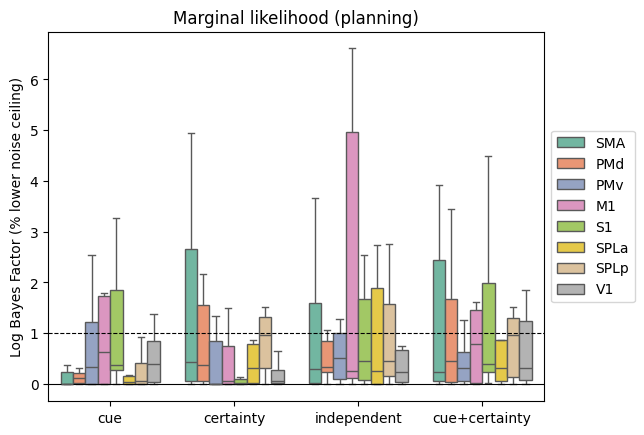

In [26]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
glm = 12
Hem = 'L'
experiment = 'smp2'

LL = pd.DataFrame()
for roi in rois:

    T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.plan.glm{glm}.{Hem}.{roi}.pkl'))
    T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.plan.glm{glm}.{Hem}.{roi}.pkl'))

    likelihood = T_cv.likelihood
    baseline = likelihood.loc[:,'null'].values
    likelihood = likelihood - baseline.reshape(-1,1)

    noise_upper = (T_gr.likelihood['ceil'] - baseline).mean()

    noise_lower_abs = likelihood.ceil.mean()

    assert noise_upper > noise_lower_abs
    print(f'noise upper: {noise_upper:.2f}, noise lower: {noise_lower_abs:.2f}')

    likelihood = likelihood / noise_lower_abs
    noise_upper = noise_upper / noise_lower_abs

    noise_lower = likelihood.ceil.mean()

    LL_tmp = pd.melt(likelihood)
    LL_tmp['roi'] = roi
    LL_tmp['noise_lower'] = noise_lower
    LL_tmp['noise_upper'] = noise_upper

    LL = pd.concat([LL, LL_tmp])

LL = LL[
    (LL['model'] == 'cue') |
    (LL['model'] == 'certainty') |
    (LL['model'] == 'cue+certainty') |
    (LL['model'] == 'independent')
]

fig, axs = plt.subplots()

sns.boxplot(ax=axs, x='model', y='value', hue='roi', data=LL, showfliers=False, palette='Set2')

axs.axhline(0, color='k', ls='-', lw=.8)
axs.axhline(1, color='k', ls='--', lw=.8)

axs.legend(bbox_to_anchor=(1, .5), loc='center left')

axs.set_ylabel('Log Bayes Factor (% lower noise ceiling)')
axs.set_xlabel('')

axs.set_title('Marginal likelihood (planning)')
plt.show()

P-values SMA:
cue         0.0000745592
certainty   0.0000141544
	
P-values PMd:
cue         0.0000093175
certainty   0.0000024364
	
P-values PMv:
cue         0.0001488692
certainty   0.0002073618
	
P-values M1:
cue         0.0000000972
certainty   0.0000000910
	
P-values S1:
cue         0.0000000001
certainty   0.0000000951
	
P-values SPLa:
cue         0.0000070071
certainty   0.0000102852
	
P-values SPLp:
cue         0.0000179425
certainty   0.0000016008
	
P-values V1:
cue         0.0000000021
certainty   0.0000000024
	


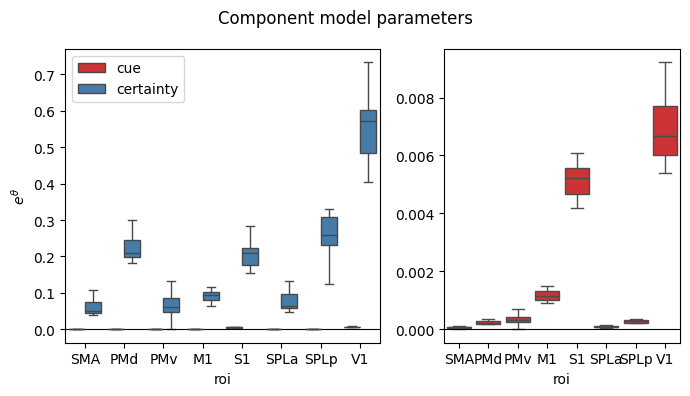

In [53]:
fig, axs = plt.subplots(1, 2, width_ratios=(2, 1.5),figsize=(7, 4))

legend_handles, legend_labels = None, None  # To store legend info

M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.plan.glm{glm}.pkl'), 'cue+certainty')
n_param = M.n_param
components = M.name.split(' ')[0]
components = M.name.split('+')

theta = {
    'sn': [],
    'roi': [],
    'model': [],
    'theta': []
}
for roi in rois:

    f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.plan.glm{glm}.{Hem}.{roi}.pkl'), "rb")
    theta_tmp = pickle.load(f)[4][:n_param]

    theta['theta'].extend(np.exp(theta_tmp.flatten()))
    theta['sn'].extend(np.tile(np.arange(theta_tmp.shape[1]), M.n_param))
    theta['roi'].extend([roi] * n_param * theta_tmp.shape[1])
    theta['model'].extend([mdl for mdl in components for _ in range(theta_tmp.shape[1])])

    _, pval = ttest_1samp(np.exp(theta_tmp).T, popmean=0)

    pval_series = pd.Series(pval, index=[
        'cue',
        'certainty',
    ])

    # Print formatted p-values
    print(f"P-values {roi}:")
    print(pval_series.to_string(float_format="%.10f"))
    print('\t')

theta = pd.DataFrame(theta)

# Create boxplot
box = sns.boxplot(ax=axs[0], data=theta, x='roi', y='theta', hue='model', showfliers=False, palette='Set1')
sns.boxplot(ax=axs[1], data=theta[theta['model']=='cue'], x='roi', y='theta', hue='model', showfliers=False, palette='Set1', legend=False)

# Store legend handles and labels (only once)
if legend_handles is None:
    legend_handles, legend_labels = box.get_legend_handles_labels()

axs[0].set_ylabel(r"$e^{\theta}$")
axs[1].set_ylabel('')
axs[0].axhline(0, color='k', ls='-', lw=.8)
axs[1].axhline(0, color='k', ls='-', lw=.8)

# Remove individual subplot legends
axs[0].get_legend().remove()
axs[0].legend(legend_handles, legend_labels, loc="upper left", ncol=1)

fig.suptitle('Component model parameters')

# Add a single figure-level legend

fig.tight_layout(rect=[0, 0, 1, 1])

plt.show()